
<br>
<font>
<div dir=ltr align=center>
<img src="https://cdn.freebiesupply.com/logos/large/2x/sharif-logo-png-transparent.png" width=150 height=150>
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Artificial Intelligence <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Spring 2025<br>
<font color=3C99D size=5>
    Project-Phase2<br>
    Soft Actor Critic<br>
<font color=696880 size=4>
    Ali Najar-Mohmmad Shafizade-Armin Khosravi




In this notebook, we are going to get familiar with SAC algorithm. Soft Actor Critic (SAC) is an off-policy algorithm that maximizes a combination of expected return **and** entropy. Higher entropy results in higher exploration, which is an important concept in Reinforcement Learning.

## 📦 Setup and Dependencies

Install PyBullet for Physics based environments.

In [31]:
# !pip install -q pybullet Box2D
# !nvidia-smi

Import necessary packages.

In [32]:
import os
import numpy as np
import torch as T
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.distributions import Normal

import warnings
warnings.filterwarnings('ignore')
from gym.wrappers import RecordVideo
import gym
import pybullet_envs
np.bool8 = np.bool_
from tqdm.notebook import trange
from IPython.display import Video

## 📈 Utility codes

We will use this utility function to visualize the training progress.

In [33]:
def plot_learning_curve(x, filename, save_plot=True):
    avg_x = [np.mean(x[np.max([0, i - 100]):i]) for i in range(len(x))]
    plt.figure(dpi=200)
    plt.title('Learning Curve')
    plt.plot(range(len(x)), x, label='score', alpha=0.3)
    plt.plot(range(len(avg_x)), avg_x, label='average score')
    plt.xlabel('Episode')
    plt.ylabel('Score')
    plt.legend()
    plt.grid()
    if save_plot:
        plt.savefig(filename + '.png')
    plt.show()

This class implements a **Replay Buffer** to store and sample transitions of the form $(s_t, a_t, r_t, s_{t+1}, d_t)$ to break correlation in updates for stability in mini-batch stochastic gradient descent.


In [34]:
class ReplayBuffer:
    def __init__(self, buffer_size, state_dims, action_dims):
        self.buffer_size = buffer_size
        self.ptr = 0
        self.is_full = False

        # TODO: Initialize buffer arrays to store states, next states, actions, rewards, and done flags
        self.state_memory = np.zeros((buffer_size, state_dims), dtype=np.float32)
        self.next_state_memory = np.zeros((buffer_size, state_dims), dtype=np.float32)
        self.action_memory = np.zeros((buffer_size, action_dims), dtype=np.float32)
        self.reward_memory = np.zeros(buffer_size, dtype=np.float32)
        self.terminal_memory = np.zeros(buffer_size, dtype=np.float32)

    def store_transition(self, state, action, reward, state_, done):
        # TODO : Store the transition in the replay buffer
        index = self.ptr
        self.state_memory[index] = state
        self.next_state_memory[index] = state_
        self.action_memory[index] = action
        self.reward_memory[index] = reward
        self.terminal_memory[index] = float(done)
        self.ptr = (self.ptr + 1) % self.buffer_size

        if self.ptr == 0:
            self.is_full = True

    def load_batch(self, batch_size):
        # TODO: Sample a random batch of transitions from the buffer
        choices_range = self.ptr if not self.is_full else self.buffer_size
        batch = np.random.choice(choices_range, batch_size, replace=False)
        states = T.tensor(self.state_memory[batch], dtype=T.float32)
        actions = T.tensor(self.action_memory[batch], dtype=T.float32)
        rewards = T.tensor(self.reward_memory[batch], dtype=T.float32)
        states_ = T.tensor(self.next_state_memory[batch], dtype=T.float32)
        done = T.tensor(self.terminal_memory[batch], dtype=T.float32)

        return states, actions, rewards, states_, done

    def __len__(self):
        return self.buffer_size if self.is_full else self.ptr


## 🧱 Neural Networks

This cell defines three core neural networks used in SAC:

- **Critic Network:**
Estimates the **Q-value function** $ Q(s, a) $. Two critics are used to mitigate overestimation bias.

- **Value Network:**
Estimates the **state value function** $ V(s) $, used to train the actor and as a baseline.

- **Actor Network:**
Outputs the **mean** and **standard deviation** for a Gaussian policy
$
\pi(a|s) = \mathcal{N}(\mu(s), \sigma(s))
$.

In [35]:
class Critic(nn.Module):
    def __init__(self, beta, state_dims, action_dims, fc1_dims, fc2_dims, name='Critic', ckpt_dir='tmp'):
        super(Critic, self).__init__()

        # TODO 1: Save input arguments as attributes
        self.beta = beta
        self.state_dims = state_dims
        self.action_dims = action_dims
        self.fc1_dims = fc1_dims
        self.fc2_dims = fc2_dims
        self.name = name
        self.ckpt_dir = ckpt_dir
        self.ckpt_path = os.path.join(self.ckpt_dir, self.name+'_sac')
        self.device = T.device('cuda' if T.cuda.is_available() else 'cpu')

        # TODO 2: Define the first fully connected layer
        # The input is the concatenation of state and action
        self.fc1 = nn.Linear(self.state_dims + self.action_dims, fc1_dims)

        # TODO 3: Define the second hidden layer and the final Q-value output layer
        self.fc2 = nn.Linear(fc1_dims, fc2_dims)
        self.final_layer = nn.Linear(fc2_dims, 1)


        # TODO 4: Define the optimizer. Assign to the correct device
        self.optimizer = optim.Adam(self.parameters(), lr = self.beta)
        self.to(self.device)


    def forward(self, state, action):
        # 1. concatenate state and action along dimension 1
        x = T.cat([state, action], dim=1)

        # 2. pass through hidden layers with ReLU activation
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        # 3. final output (Q-value)
        q = self.final_layer(x)

        return q


    def save_checkpoint(self):
        T.save(self.state_dict(), self.ckpt_path)

    def load_checkpoint(self, gpu_to_cpu=False):
        if gpu_to_cpu:
            self.load_state_dict(T.load(self.ckpt_path, map_location=lambda storage, loc: storage))
        else:
            self.load_state_dict(T.load(self.ckpt_path))


class Actor(nn.Module):
    def __init__(self, alpha, state_dims, action_dims, fc1_dims, fc2_dims, max_action, reparam_noise,
                 name='Actor', ckpt_dir='tmp'):
        super(Actor, self).__init__()
        # TODO 1: Store initialization parameters
        self.alpha = alpha
        self.state_dims = state_dims
        self.action_dims = action_dims
        self.fc1_dims = fc1_dims
        self.fc2_dims = fc2_dims
        self.max_action = max_action
        self.reparam_noise = reparam_noise
        self.name = name
        self.ckpt_dir = ckpt_dir
        self.ckpt_path = os.path.join(ckpt_dir, name+'_sac')
        self.device = T.device('cuda' if T.cuda.is_available() else 'cpu')


        # TODO 2: Define fully connected layers to transform input state
        self.fc1 = nn.Linear(state_dims, fc1_dims)
        self.fc2 = nn.Linear(fc1_dims, fc2_dims)

        # TODO 3: Output mean and standard deviation for the Gaussian policy
        self.mean = nn.Linear(fc2_dims, action_dims)
        self.log_std = nn.Linear(fc2_dims, action_dims)

        # TODO 4: Define optimizer and move model to the appropriate device
        self.optimizer = optim.Adam(self.parameters(), lr=self.alpha)
        self.to(self.device)


    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        mu = self.mean(x)
        log_std = self.log_std(x).clamp(-20, 2) #Addition : -20 , 2
        sigma = log_std.exp()
        return mu, sigma

    def sample_normal(self, state, reparameterize=True):
        # TODO 7: Use the actor to compute distribution parameters
        mean, std = self.forward(state)
        normal = Normal(mean, std)

        # TODO 8: Create a normal distribution and sample from it
        z = normal.rsample() if reparameterize else normal.sample()
        y = T.tanh(z)  #Addition : we need it to be in [-1.1]


        action = y * self.max_action
        log_probs = normal.log_prob(z) - T.log(1 - y.pow(2) + 1e-6) #Addition : 1e-6
        log_probs = log_probs.sum(dim=1, keepdim=True)  # sum over action dimensions


        return action, log_probs

    def save_checkpoint(self):
        T.save(self.state_dict(), self.ckpt_path)

    def load_checkpoint(self, gpu_to_cpu=False):
        if gpu_to_cpu:
            self.load_state_dict(T.load(self.ckpt_path, map_location=lambda storage, loc: storage))
        else:
            self.load_state_dict(T.load(self.ckpt_path))


class Value(nn.Module):
    def __init__(self, beta, state_dims, fc1_dims, fc2_dims, name='Value', ckpt_dir='tmp'):
        super(Value, self).__init__()

        # TODO 1: Save arguments as instance variables
        self.beta = beta
        self.state_dims = state_dims
        self.fc1_dims = fc1_dims
        self.fc2_dims = fc2_dims
        self.name = name
        self.ckpt_dir = ckpt_dir
        self.ckpt_path = os.path.join(ckpt_dir, name+'_sac_value')


        # TODO 2: Define the fully connected layers for value approximation
        self.fc1 = nn.Linear(state_dims, fc1_dims)
        self.fc2 = nn.Linear(fc1_dims, fc2_dims)
        self.v = nn.Linear(fc2_dims, 1)

        #Addition
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)


        # TODO 3: Set optimizer and device
        self.optimizer = optim.Adam(self.parameters(), lr=beta)
        self.device = T.device('cuda' if T.cuda.is_available() else 'cpu')
        self.to(self.device)


    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        v = self.v(x)
        return v

    def save_checkpoint(self):
        T.save(self.state_dict(), self.ckpt_path)

    def load_checkpoint(self, gpu_to_cpu=False):
        if gpu_to_cpu:
            self.load_state_dict(T.load(self.ckpt_path, map_location=lambda storage, loc: storage))
        else:
            self.load_state_dict(T.load(self.ckpt_path))

## 🤖 Agent Implementation

This class encapsulates the full logic of the SAC agent. In general, the learning process uses entropy-regularized policy gradients $J_\pi = \mathbb{E}_{s_t \sim D, a_t \sim \pi} \left[ \alpha \log(\pi(a_t|s_t)) - Q(s_t, a_t) \right]$ with soft target updates $\theta_{\text{target}} \leftarrow \tau \theta + (1 - \tau)\theta_{\text{target}}$.

In [36]:
class Agent:
    def __init__(self, gamma, alpha, beta, state_dims, action_dims, max_action, fc1_dim, fc2_dim,
                 memory_size, batch_size, tau, update_period, reward_scale, warmup, reparam_noise_lim,
                 name, ckpt_dir='tmp'):
        # TODO 1: Save all hyperparameters and paths
        self.gamma = gamma
        self.alpha = alpha
        self.beta = beta
        self.state_dims = state_dims
        self.action_dims = action_dims
        self.max_action = max_action
        self.fc1_dim = fc1_dim
        self.fc2_dim = fc2_dim
        self.memory_size = memory_size
        self.batch_size = batch_size
        self.tau = tau
        self.update_period = update_period
        self.reward_scale = reward_scale
        self.warmup = warmup
        self.reparam_noise_lim = reparam_noise_lim
        self.name = name
        self.ckpt_dir = ckpt_dir
        self.device = T.device('cuda' if T.cuda.is_available() else 'cpu')


        model_name = f'{name}__' \
                     f'gamma_{gamma}__' \
                     f'alpha_{alpha}__' \
                     f'beta_{beta}__' \
                     f'fc1_{fc1_dim}__' \
                     f'fc2_{fc2_dim}__' \
                     f'bs_{batch_size}__' \
                     f'buffer_{memory_size}__' \
                     f'update_period_{update_period}__' \
                     f'tau_{tau}__'

        self.model_name = model_name
        self.learn_iter = 0
        self.full_path = os.path.join(self.ckpt_dir, self.model_name)

        # TODO 2: Initialize the replay buffer
        self.memory = ReplayBuffer(memory_size, state_dims, action_dims)


        # TODO 3: Initialize Actor and Critic networks
        self.actor = Actor(alpha, state_dims, action_dims, fc1_dim, fc2_dim, max_action, reparam_noise_lim, name+'_actor', ckpt_dir)
        self.critic_1 = Critic(beta, state_dims, action_dims, fc1_dim, fc2_dim, name+'_critic1', ckpt_dir)
        self.critic_2 = Critic(beta, state_dims, action_dims, fc1_dim, fc2_dim, name+'_critic2', ckpt_dir)


        # TODO 4: Initialize Value and Target Value networks
        self.value = Value(beta, state_dims, fc1_dim, fc2_dim, name+'_value', ckpt_dir)
        self.target_value = Value(beta, state_dims, fc1_dim, fc2_dim, name+'_target_value', ckpt_dir)



        # TODO 5: Sync the parameters of value and target_value networks initially
        self.target_value.load_state_dict(self.value.state_dict())

    def choose_action(self, state, deterministic=False, reparameterize=False):

        # TODO 6: Convert state to tensor, move to device, and add batch dimension
        if isinstance(state, np.ndarray):
            state_t = T.tensor(state, dtype=T.float32, device=self.device).unsqueeze(0)
        elif T.is_tensor(state):
            state_t = state.to(self.device).unsqueeze(0) if state.dim() == 1 else state.to(self.device)
        else:
            state_t = T.tensor(state, dtype=T.float32, device=self.device).unsqueeze(0)

        # TODO 7: Choose action from actor
        if deterministic:
            with T.no_grad():
                mean, _ = self.actor.forward(state_t)
                action = T.tanh(mean) * T.tensor(self.max_action, device=self.device)
            return action.squeeze(0).cpu().numpy()
        else:
            with T.no_grad():
                action, _logp = self.actor.sample_normal(state_t, reparameterize=reparameterize)
            return action.squeeze(0).cpu().numpy()

    def store_transition(self, state, action, reward, state_, done):
        self.memory.store_transition(state, action, reward, state_, done)

    def load_batch(self):
        return self.memory.load_batch(self.batch_size)

    def update_parameters(self, tau=None):
        tau = self.tau if tau is None else tau
        with T.no_grad():
            for t_param, s_param in zip(self.target_value.parameters(), self.value.parameters()):
                t_param.data.copy_(tau * s_param.data + (1.0 - tau) * t_param.data)


    def save_model(self):
        print('... saving checkpoint ...')
        self.actor.save_checkpoint()
        self.critic_1.save_checkpoint()
        self.critic_2.save_checkpoint()
        self.value.save_checkpoint()
        self.target_value.save_checkpoint()

    def load_model(self, gpu_to_cpu=False):
        print('... loading checkpoint ...')
        self.actor.load_checkpoint(gpu_to_cpu=gpu_to_cpu)
        self.critic_1.load_checkpoint(gpu_to_cpu=gpu_to_cpu)
        self.critic_2.load_checkpoint(gpu_to_cpu=gpu_to_cpu)
        self.value.load_checkpoint(gpu_to_cpu=gpu_to_cpu)
        self.target_value.load_checkpoint(gpu_to_cpu=gpu_to_cpu)

    def learn(self):
        # TODO 11: Skip learning during warm-up period or insufficient samples
        # Robust count (fallbacks if your buffer uses different fields)
        try:
            num_in_buffer = len(self.memory)
        except Exception:
            num_in_buffer = getattr(self.memory, "buffer_size", 0) if getattr(self.memory, "is_full", False) \
                            else getattr(self.memory, "ptr", 0)
        if num_in_buffer < self.batch_size or (self.warmup and num_in_buffer < self.warmup):
            return

        # === VALUE LOSS ===
        # TODO 12: Load batch and sample action
        states, actions, rewards, next_states, dones = self.load_batch()
        device = getattr(self.actor, "device", self.device)

        # move everything to device (and fix shapes)
        states      = states.to(device, non_blocking=True)
        actions     = actions.to(device, non_blocking=True)
        rewards     = rewards.to(device, non_blocking=True)
        next_states = next_states.to(device, non_blocking=True)
        dones       = dones.to(device, non_blocking=True)

        if rewards.dim() == 1: rewards = rewards.unsqueeze(1)
        if dones.dim()   == 1: dones   = dones.unsqueeze(1)

        # ===== VALUE LOSS =====
        # sample actions from current policy (no reparam for value target)
        with T.no_grad():
            actions_pi, log_probs_pi = self.actor.sample_normal(states, reparameterize=False)
            log_probs_pi = T.nan_to_num(log_probs_pi, nan=0.0, posinf=0.0, neginf=0.0)

        # TODO 13: Estimate Q-values
        q1_pi = self.critic_1(states, actions_pi)   # (B,1)
        q2_pi = self.critic_2(states, actions_pi)   # (B,1)
        q_pi_min = T.min(q1_pi, q2_pi)

        # TODO 14: Compute target value
        # V target = E[min Q - alpha * log π]
        target_v = q_pi_min - self.alpha * log_probs_pi
        target_v = T.nan_to_num(target_v, nan=0.0, posinf=0.0, neginf=0.0)

        # TODO 15: Compute value loss and update value network
        v_pred = self.value(states)
        v_loss = 0.5 * F.mse_loss(v_pred, target_v.detach())

        self.value.optimizer.zero_grad(set_to_none=True)
        v_loss.backward()
        T.nn.utils.clip_grad_norm_(self.value.parameters(), max_norm=1.0)
        self.value.optimizer.step()

        # ===== ACTOR LOSS =====
         # TODO 16: Re-sample actions (this time with reparameterization for gradients)
        actions_reparam, log_probs = self.actor.sample_normal(states, reparameterize=True)
        log_probs = T.nan_to_num(log_probs, nan=0.0, posinf=0.0, neginf=0.0)

        # TODO 17: maximize entropy-regularized Q-value
        q1_val = self.critic_1(states, actions_reparam)
        q2_val = self.critic_2(states, actions_reparam)
        min_q  = T.min(q1_val, q2_val)

        # maximize (min_q - alpha * logπ)  <=>  minimize (alpha*logπ - min_q)
        actor_loss = (self.alpha * log_probs - min_q).mean()

        self.actor.optimizer.zero_grad(set_to_none=True)
        actor_loss.backward()
        T.nn.utils.clip_grad_norm_(self.actor.parameters(), max_norm=1.0)
        self.actor.optimizer.step()

        # ===== CRITIC LOSSES =====
        # TODO 18: Compute Q targets
        with T.no_grad():
            v_next = self.target_value(next_states)
            v_next = v_next * (1.0 - dones)                         # zero for terminals
            q_tgt  = (self.reward_scale * rewards) + (self.gamma * v_next)
            q_tgt  = T.nan_to_num(q_tgt, nan=0.0, posinf=0.0, neginf=0.0)

        # TODO 19: Compute MSE loss for both critics
        q1_pred = self.critic_1(states, actions)
        q2_pred = self.critic_2(states, actions)

        c1_loss = 0.5 * F.mse_loss(q1_pred, q_tgt)
        c2_loss = 0.5 * F.mse_loss(q2_pred, q_tgt)

        self.critic_1.optimizer.zero_grad(set_to_none=True)
        c1_loss.backward()
        T.nn.utils.clip_grad_norm_(self.critic_1.parameters(), max_norm=1.0)
        self.critic_1.optimizer.step()

        self.critic_2.optimizer.zero_grad(set_to_none=True)
        c2_loss.backward()
        T.nn.utils.clip_grad_norm_(self.critic_2.parameters(), max_norm=1.0)
        self.critic_2.optimizer.step()

        # ===== TARGET VALUE POLYAK UPDATE =====
        if (self.learn_iter + 1) % max(1, int(self.update_period)) == 0:
            self.update_parameters(self.tau)

        # TODO 21: Increase learning iteration counter
        self.learn_iter += 1


## ⚙️ Training Configuration

Set up your training parameters. `HalfCheetahBulletEnv-v0` is a continuous control task where the agent must learn to run using articulated legs.


In [37]:
# Configuration parameters


env_name = 'HalfCheetahBulletEnv-v0'
dir = 'tmp'
n_games = None


gamma = 0.99
alpha = 3e-4
beta = 3e-4
fc1_dim = 256
fc2_dim = 256
# Add other network dims if needed
memory_size = 35000
batch_size = 128
tau = 0.005
update_period = 2
reward_scale = 2.0
warmup = 1000
reparam_noise_lim = 1e-6
record_video = True

## 🚀 Training Loop

For each episode, interact with the environment to collect transitions, then update the SAC networks and save the best model.

After training, a learning curve is plotted to visualize convergence and performance stability.

  0%|          | 0/500 [00:00<?, ?it/s]

| Game:      0 | Score:   -1384.86 | Best score:   -1384.86 | Avg score   -1384.86 | Learning iter:          1 |
... saving checkpoint ...
| Game:      1 | Score:   -1343.93 | Best score:   -1343.93 | Avg score   -1364.39 | Learning iter:       1001 |
... saving checkpoint ...
| Game:      2 | Score:   -1370.64 | Best score:   -1343.93 | Avg score   -1366.47 | Learning iter:       2001 |
| Game:      3 | Score:   -1077.09 | Best score:   -1077.09 | Avg score   -1294.13 | Learning iter:       3001 |
... saving checkpoint ...
| Game:      4 | Score:   -1209.58 | Best score:   -1077.09 | Avg score   -1277.22 | Learning iter:       4001 |
... saving checkpoint ...
| Game:      5 | Score:   -1235.73 | Best score:   -1077.09 | Avg score   -1270.30 | Learning iter:       5001 |
... saving checkpoint ...
| Game:      6 | Score:   -1137.74 | Best score:   -1077.09 | Avg score   -1251.37 | Learning iter:       6001 |
... saving checkpoint ...
| Game:      7 | Score:   -1174.85 | Best score:   -1

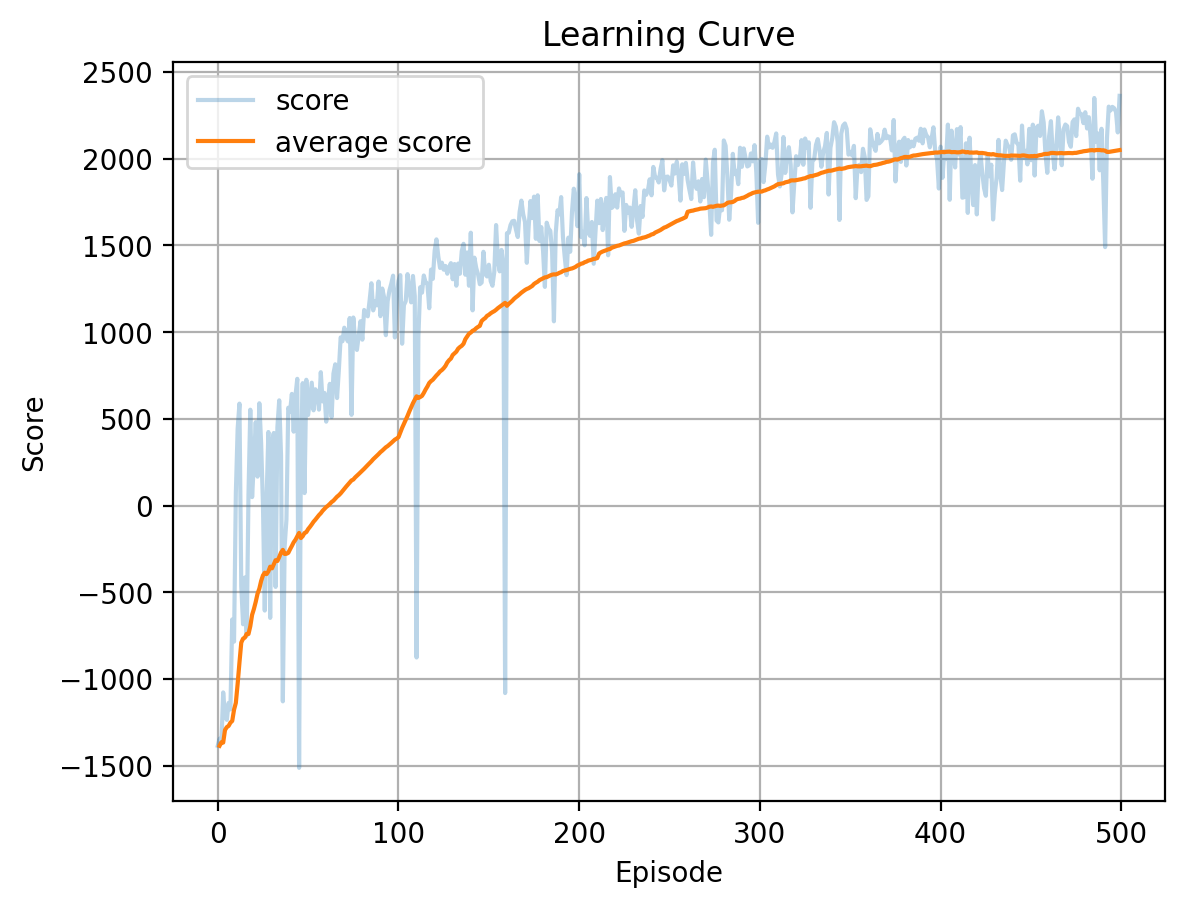

In [38]:
env = gym.make(env_name)
dir_path = os.path.join(dir, env_name)
os.makedirs(dir_path, exist_ok=True)



n_games = 500  # increase for better learning (e.g., 1000)
start_steps = 1000  # steps collecting random actions before training

if record_video:
    env = RecordVideo(env, video_folder=os.path.join(dir_path, 'videos'),
                      episode_trigger=lambda ep: ep == n_games - 1)
agent = Agent(
    gamma, alpha, beta,
    env.observation_space.shape[0],
    env.action_space.shape[0],
    env.action_space.high[0],
    fc1_dim, fc2_dim,
    memory_size, batch_size,
    tau, update_period,
    reward_scale, warmup,
    reparam_noise_lim,
    name='SAC',
    ckpt_dir=dir
)


# TODO: Initialize performance tracking variables
updates_per_step = 1
best_avg = -np.inf
scores = []
total_steps = 0
# Initialize best_score
best_score = -np.inf


for game in trange(n_games):
    # TODO: Reset environment and initialize variables at the start of each episode
    done = False
    score = 0.0
    state = env.reset()


    # TODO: Interact with the environment until the episode is done
    while not done:
        # Use random actions during warmup to prevent NaNs
        if total_steps < agent.warmup:
            action = env.action_space.sample()
        else:
            action = agent.choose_action(state, reparameterize=False)
        next_state, reward, done, info = env.step(action)
        agent.store_transition(state, action, reward, next_state, done)
        state = next_state
        score += reward
        total_steps += 1

        if total_steps >= start_steps:
            for _ in range(updates_per_step):
                agent.learn()



    # TODO: Track score and average score for plotting and saving
    scores.append(score)
    avg_score = np.mean(scores[-10:])
    best_score = max(best_score, score)

    print(f'| Game: {game:6.0f} | Score: {score:10.2f} | Best score: {best_score:10.2f} | '
          f'Avg score {avg_score:10.2f} | Learning iter: {agent.learn_iter:10.0f} |')


    # TODO: Save the model if the current avg score is better than the best so far
    if avg_score > best_avg:
        best_avg = avg_score
        agent.save_model()


env.close()

plot_learning_curve(scores, agent.full_path)

## 🎥 Visualize Agent Behavior

This is the last episode recorded video of the trained agent interacting with the environment in training process.

In [43]:
Video(f"/content/tmp/HalfCheetahBulletEnv-v0/videos/rl-video-episode-{n_games-1}.mp4", embed=True, width=600)